# Exploratory Data Analysis — Drone-Strike Forecasting Panel

Companion notebook executing the seven-block EDA programme on the **raw** target $y_{r,t}$ 
(no log or other variance-stabilising transform).

Input: `master_combined_timeseries.parquet` — wide-format panel with 847 daily observations 
and 1 622 columns, including 25 region-specific target columns `act_drone_strike_on_ua_<region>`. 
Tier-0 regions (`chernivtsi`, `crimea`, `ternopil`, `volyn`, `zakarpattia`) are excluded 
from every analytical block per §3.3 of the thesis.

**Blocks:**
1. Distributional structure of the raw target  
2. Temporal structure (ACF / PACF, STL, rolling moments)  
3. Stationarity diagnostics (ADF, KPSS, PELT change points)  
4. Cross-regional structure (lagged correlation, hierarchical clustering)  
5. Covariate–target relationships (within-region Spearman, CCF, multicollinearity)  
6. Missingness audit  
7. Train / validation / test split-shift diagnostics

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import spearmanr, wasserstein_distance, ks_2samp
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
import ruptures as rpt
import warnings, json
warnings.filterwarnings('ignore')
from src import *

DATA_FOLDER       = "./data"
FIXED_DATA_PATH   = construct_path(DATA_FOLDER, "fixed")
DATASET_PATH      = construct_path(DATA_FOLDER, "dataset")
EDA_DATA_PATH = construct_path(DATA_FOLDER, "for_eda")
EDA_PLOT_DATA_PATH = construct_path(EDA_DATA_PATH, "plots")

PARQUET_PATH = construct_path(DATASET_PATH, "master_combined_timeseries.parquet")
OUTPUT_DIR   = EDA_PLOT_DATA_PATH
TARGET_PREFIX = 'act_drone_strike_on_ua_'

df = pd.read_parquet(PARQUET_PATH)
df['event_date'] = pd.to_datetime(df['event_date'])
df = df.sort_values('event_date').reset_index(drop=True)
print(df.shape, df['event_date'].min().date(), '→', df['event_date'].max().date())

(847, 1622) 2022-09-28 → 2025-01-21


In [3]:
# Region discovery and tier assignment per §3.3
def tier_of(n_active_days):
    """Activity tier as defined in §3.3 of the thesis."""
    if n_active_days < 7:    return 0
    if n_active_days < 84:   return 1
    if n_active_days < 219:  return 2
    return 3

target_cols   = [c for c in df.columns if c.startswith(TARGET_PREFIX)]
regions_all   = [c.replace(TARGET_PREFIX, '') for c in target_cols]
active_days   = {r: int((df[TARGET_PREFIX + r] > 0).sum()) for r in regions_all}
tier          = {r: tier_of(n) for r, n in active_days.items()}
modelled      = [r for r, t in tier.items() if t > 0]
tier0         = [r for r, t in tier.items() if t == 0]

# Long-format panel of raw target
tlong = (df[['event_date'] + [TARGET_PREFIX + r for r in modelled]]
           .melt('event_date', var_name='col', value_name='y'))
tlong['region'] = tlong['col'].str.replace(TARGET_PREFIX, '', regex=False)
tlong['tier']   = tlong['region'].map(tier)
tlong = tlong[['event_date', 'region', 'tier', 'y']].sort_values(['region','event_date']).reset_index(drop=True)

# Chronological 70/10/20 split, identical to every region
n_days = df['event_date'].nunique()
dates  = sorted(df['event_date'].unique())
TRAIN_END = pd.Timestamp(dates[int(0.70 * n_days) - 1])
VAL_END   = pd.Timestamp(dates[int(0.80 * n_days) - 1])
tlong['split'] = np.where(tlong['event_date'] <= TRAIN_END, 'train',
                   np.where(tlong['event_date'] <= VAL_END,   'val', 'test'))

print(f'Modelled regions: {len(modelled)}; Tier-0 excluded: {tier0}')
print(f'Train end: {TRAIN_END.date()},  Val end: {VAL_END.date()}')

Modelled regions: 20; Tier-0 excluded: ['chernivtsi', 'crimea', 'ternopil', 'volyn', 'zakarpattia']
Train end: 2024-05-11,  Val end: 2024-08-04


## Block 1 — Distributional structure of the raw target

In [4]:
def marginal_stats(y):
    """Pooled marginal moments for a 1-D array of counts."""
    y  = np.asarray(y)
    mu = y.mean()
    s2 = y.var(ddof=1)
    return dict(n=len(y), zero_rate=float((y==0).mean()),
                mean=float(mu), var=float(s2),
                disp_I=float(s2/max(mu,1e-12)),
                p95=float(np.quantile(y,0.95)),
                p99=float(np.quantile(y,0.99)),
                p999=float(np.quantile(y,0.999)),
                max=int(y.max()))

def fit_poisson_nb(y):
    """Pooled Poisson MLE and NB method-of-moments.  Returns log-likelihoods + parameters."""
    y  = np.asarray(y)
    mu = y.mean(); s2 = y.var(ddof=1)
    ll_poi = stats.poisson.logpmf(y, mu).sum()
    if s2 > mu:
        k    = mu**2 / (s2 - mu)
        p    = k / (k + mu)
        ll_nb = stats.nbinom.logpmf(y, k, p).sum()
    else:
        k, p, ll_nb = np.inf, 1.0, -np.inf
    return dict(mu=mu, k_nb=k, p_nb=p, ll_poisson=float(ll_poi), ll_nb=float(ll_nb))

stats_pooled = marginal_stats(tlong['y'].values)
stats_by_tier = {int(t): marginal_stats(sub['y'].values) for t, sub in tlong.groupby('tier')}
fits = fit_poisson_nb(tlong['y'].values)
print(stats_pooled); print(stats_by_tier); print(fits)

{'n': 16940, 'zero_rate': 0.8559622195985832, 'mean': 0.3938606847697757, 'var': 2.152793052200015, 'disp_I': 5.465874446083371, 'p95': 3.0, 'p99': 7.0, 'p999': 16.0, 'max': 37}
{1: {'n': 8470, 'zero_rate': 0.9772136953955136, 'mean': 0.024793388429752067, 'var': 0.028432328306736577, 'disp_I': 1.1467705750383752, 'p95': 0.0, 'p99': 1.0, 'p999': 2.0, 'max': 3}, 2: {'n': 3388, 'zero_rate': 0.8887249114521841, 'mean': 0.14551357733175915, 'var': 0.2956190748082204, 'disp_I': 2.031556643915316, 'p95': 1.0, 'p99': 2.0, 'p999': 6.0, 'max': 11}, 3: {'n': 5082, 'zero_rate': 0.6320346320346321, 'mean': 1.1745375836284928, 'var': 6.0547500813464925, 'disp_I': 5.155007524443437, 'p95': 6.0, 'p99': 11.0, 'p999': 22.0, 'max': 37}}
{'mu': np.float64(0.3938606847697757), 'k_nb': np.float64(0.0881934074781696), 'p_nb': np.float64(0.1829533425738603), 'll_poisson': -18652.085509852433, 'll_nb': -11240.110023656442}


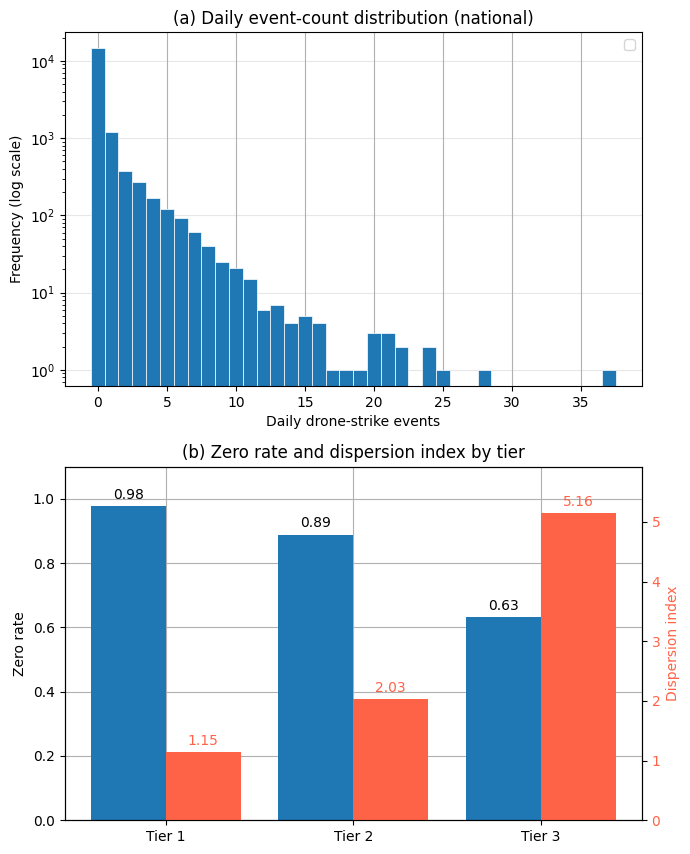

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def plot_distribution(tlong, savepath):
    y = tlong['y'].values
    fig, axes = plt.subplots(2, 1, figsize=(7, 9))

    bins = np.arange(0, min(y.max(), 40) + 2) - 0.5
    axes[0].hist(np.clip(y, 0, 40), bins=bins, edgecolor='white', linewidth=0.5)
    axes[0].set_yscale('log')
    axes[0].set_xlabel('Daily drone-strike events')
    axes[0].set_ylabel('Frequency (log scale)')
    # axes[0].axvline(np.quantile(y, 0.95), ls=':',  color='C3', lw=1, label='95th pctile')
    # axes[0].axvline(np.quantile(y, 0.99), ls='--', color='C3', lw=1, label='99th pctile')
    axes[0].legend()
    
    # Set axis below BEFORE drawing the grid
    axes[0].set_axisbelow(True)
    axes[0].grid(alpha=0.3, axis='y')

    tiers = sorted(tlong['tier'].unique())
    zr  = [(tlong[tlong.tier==t].y == 0).mean() for t in tiers]
    dsp = [tlong[tlong.tier==t].y.var(ddof=1)/max(tlong[tlong.tier==t].y.mean(),1e-12) for t in tiers] # Variance / Mean
    
    x = np.arange(len(tiers))
    w = 0.4
    
    # Store the zero rate bars in a variable and label them
    bars_zr = axes[1].bar(x - w/2, zr, w, label='Zero rate')
    axes[1].bar_label(bars_zr, fmt='%.2f', padding=3) # Adds the labels on top
    
    axes[1].set_ylabel('Zero rate')
    axes[1].tick_params(axis='y')
    axes[1].set_ylim(0, 1.1) # Slightly increased to accommodate labels

    ax2 = axes[1].twinx()
    
    # Store the dispersion bars in a variable and label them
    bars_dsp = ax2.bar(x + w/2, dsp, w, color='tomato')
    ax2.bar_label(bars_dsp, fmt='%.2f', padding=3, color='tomato') # Adds the labels on top
    
    ax2.set_ylabel('Dispersion index', color='tomato')
    ax2.tick_params(axis='y', labelcolor='tomato')
    
    # Add a dynamic y-limit to ax2 to ensure the text doesn't get cut off at the top
    ax2.set_ylim(0, max(dsp) * 1.15) 
    
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f'Tier {t}' for t in tiers])
    
    # Set axis below BEFORE drawing the secondary grids
    axes[0].set_axisbelow(True) 
    axes[1].set_axisbelow(True)
    
    axes[0].grid(linestyle='-', axis="both")
    axes[1].grid(linestyle='-', axis="both")
    
    axes[0].set_title('(a) Daily event-count distribution (national)')
    axes[1].set_title('(b) Zero rate and dispersion index by tier')
    # fig.suptitle(r'Distribution and over-dispersion of the daily target $y_{r,t}$',
                #  fontsize=13, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(savepath, bbox_inches='tight')
    plt.show()

plot_distribution(tlong, f'{OUTPUT_DIR}/fig_eda1_target_distribution.svg')

## Block 2 — Temporal structure

In [6]:
def per_region_pacf(panel, max_lag=30, method='ywm'):
    """Per-region PACF on raw counts.  Returns (n_regions, max_lag+1) array and region order."""
    out, regs = [], []
    for r, sub in panel.groupby('region'):
        x = sub.sort_values('event_date')['y'].values.astype(float)
        out.append(pacf(x, nlags=max_lag, method=method))
        regs.append(r)
    return np.array(out), regs

def per_region_acf(panel, max_lag=30):
    out, regs = [], []
    for r, sub in panel.groupby('region'):
        x = sub.sort_values('event_date')['y'].values.astype(float)
        out.append(acf(x, nlags=max_lag, fft=True))
        regs.append(r)
    return np.array(out), regs

def significant_lags(pacf_mat, n_obs, share_threshold=0.5):
    """Lags where at least `share_threshold` of regions exceed the white-noise band."""
    ci = 1.96 / np.sqrt(n_obs)
    sig = np.abs(pacf_mat) > ci
    pct = sig.mean(axis=0)
    return [int(L) for L in range(1, pacf_mat.shape[1]) if pct[L] >= share_threshold]

MAX_LAG = 30
P, regs_order = per_region_pacf(tlong, MAX_LAG)
A, _          = per_region_acf(tlong, MAX_LAG)
tiers_arr = np.array([tier[r] for r in regs_order])
for t in [1, 2, 3]:
    sub = P[tiers_arr == t]
    print(f'Tier {t}: significant lags ≥50% = {significant_lags(sub, 847)}')

Tier 1: significant lags ≥50% = []
Tier 2: significant lags ≥50% = [1, 3, 5, 7, 10, 13, 17, 27]
Tier 3: significant lags ≥50% = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 14, 16, 21, 29]


In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

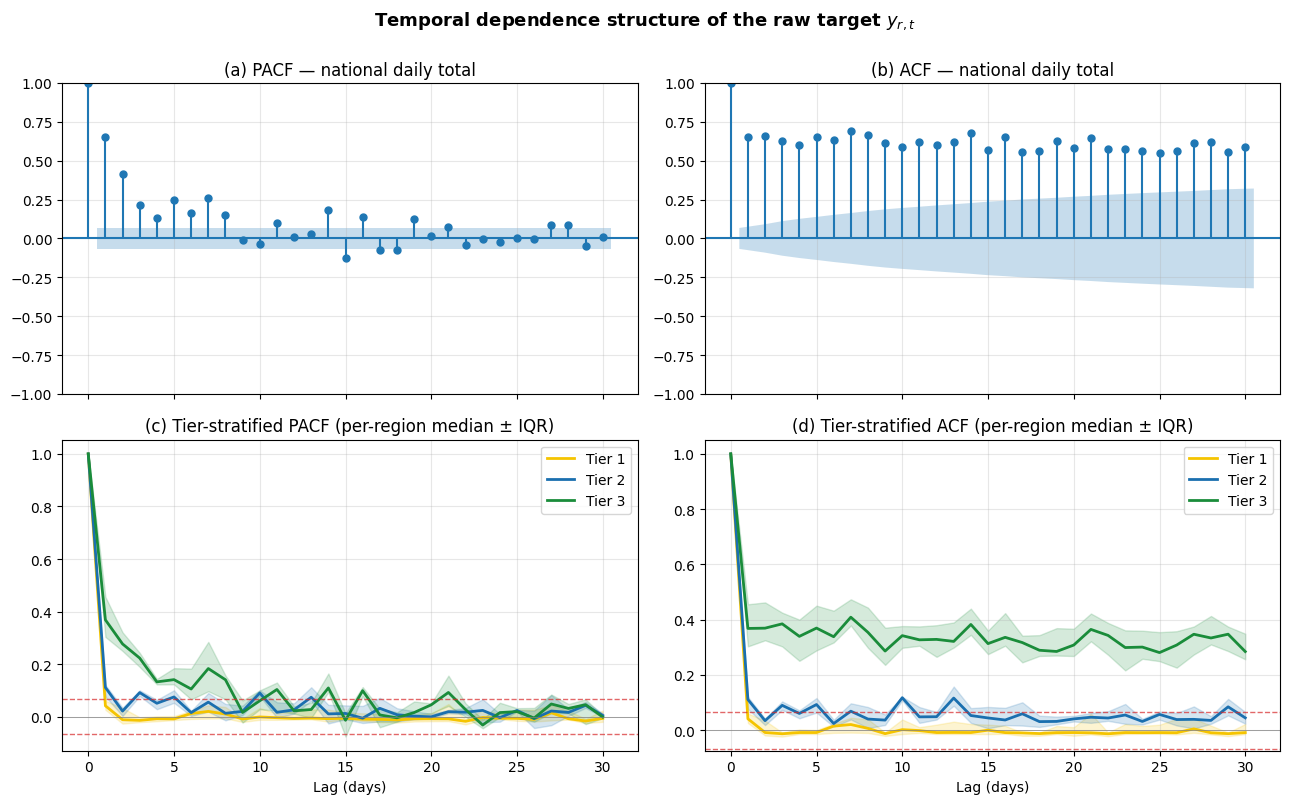

In [8]:
def plot_acf_pacf_composite(tlong, P, A, tiers_arr, max_lag=30, savepath=None):
    """Composite: national PACF/ACF + tier-stratified median±IQR PACF/ACF."""
    nat = tlong.groupby('event_date')['y'].sum().sort_index().values.astype(float)
    ci_reg = 1.96 / np.sqrt(len(tlong) // len(tlong['region'].unique()))
    lags = np.arange(max_lag + 1)
    colors = {1:'#f5c400', 2:'#1a6faf', 3:'#1a8c3a'}

    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

    plot_pacf(nat, lags=max_lag, method='ywm', ax=axes[0,0], title='(a) PACF — national daily total')
    axes[0,0].grid(alpha=0.3)
    plot_acf(nat, lags=max_lag, fft=True, ax=axes[0,1], title='(b) ACF — national daily total')
    axes[0,1].grid(alpha=0.3)

    for ax, M, label in [
        (axes[1,0], P, '(c) Tier-stratified PACF (per-region median ± IQR)'),
        (axes[1,1], A, '(d) Tier-stratified ACF (per-region median ± IQR)'),
    ]:
        for t in [1,2,3]:
            mask = (tiers_arr == t)
            med  = np.median(M[mask], axis=0)
            q25  = np.percentile(M[mask], 25, axis=0)
            q75  = np.percentile(M[mask], 75, axis=0)
            ax.plot(lags, med, color=colors[t], lw=2, label=f'Tier {t}')
            ax.fill_between(lags, q25, q75, color=colors[t], alpha=0.18)
        ax.axhline(ci_reg, ls='--', color='C3', lw=1, alpha=0.7)
        ax.axhline(-ci_reg, ls='--', color='C3', lw=1, alpha=0.7)
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_title(label); ax.set_xlabel('Lag (days)'); ax.legend(); ax.grid(alpha=0.3)

    plt.suptitle('Temporal dependence structure of the raw target $y_{r,t}$', fontsize=13, fontweight='bold', y=1.00)
    plt.tight_layout()
    if savepath: plt.savefig(savepath, bbox_inches='tight')
    plt.show()

plot_acf_pacf_composite(tlong, P, A, tiers_arr, MAX_LAG, f'{OUTPUT_DIR}/fig_eda2_acf_pacf.svg')

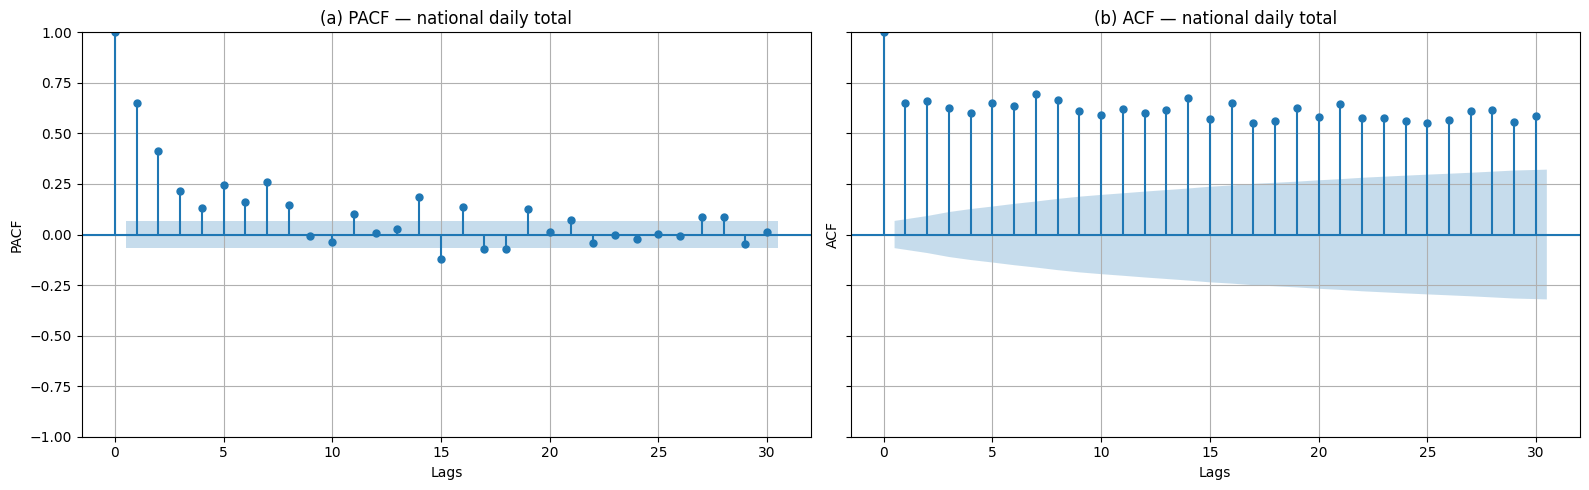

In [ ]:
# Standalone Pacf 

def plot_acf_pacf_composite(tlong, P, A, tiers_arr, max_lag=30, savepath=None):
    """Composite: national PACF/ACF + tier-stratified median±IQR PACF/ACF."""
    nat = tlong.groupby('event_date')['y'].sum().sort_index().values.astype(float)

    fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharey=False, sharex=True)

    plot_pacf(nat, lags=max_lag, method='ywm', ax=axes[0], title='(a) PACF — national daily total')
    plot_acf(nat, lags=max_lag, fft=True, ax=axes[1], title='(b) ACF — national daily total')
    
    # Set x and y labels for PACF
    axes[0].set_xlabel('Lags')
    axes[0].set_ylabel('PACF')
    
    # Set x and y labels for ACF
    axes[1].set_xlabel('Lags')
    axes[1].set_ylabel('ACF')

    # plt.suptitle('Temporal dependence structure of the raw target $y_{r,t}$', fontsize=13, fontweight='bold', y=1.00)
    axes[0].grid()
    axes[1].grid()
    
    plt.tight_layout()
    if savepath: plt.savefig(savepath, bbox_inches='tight')
    plt.show()

plot_acf_pacf_composite(tlong, P, A, tiers_arr, MAX_LAG, f'{OUTPUT_DIR}/fig_eda2_onlypacfacf.svg')

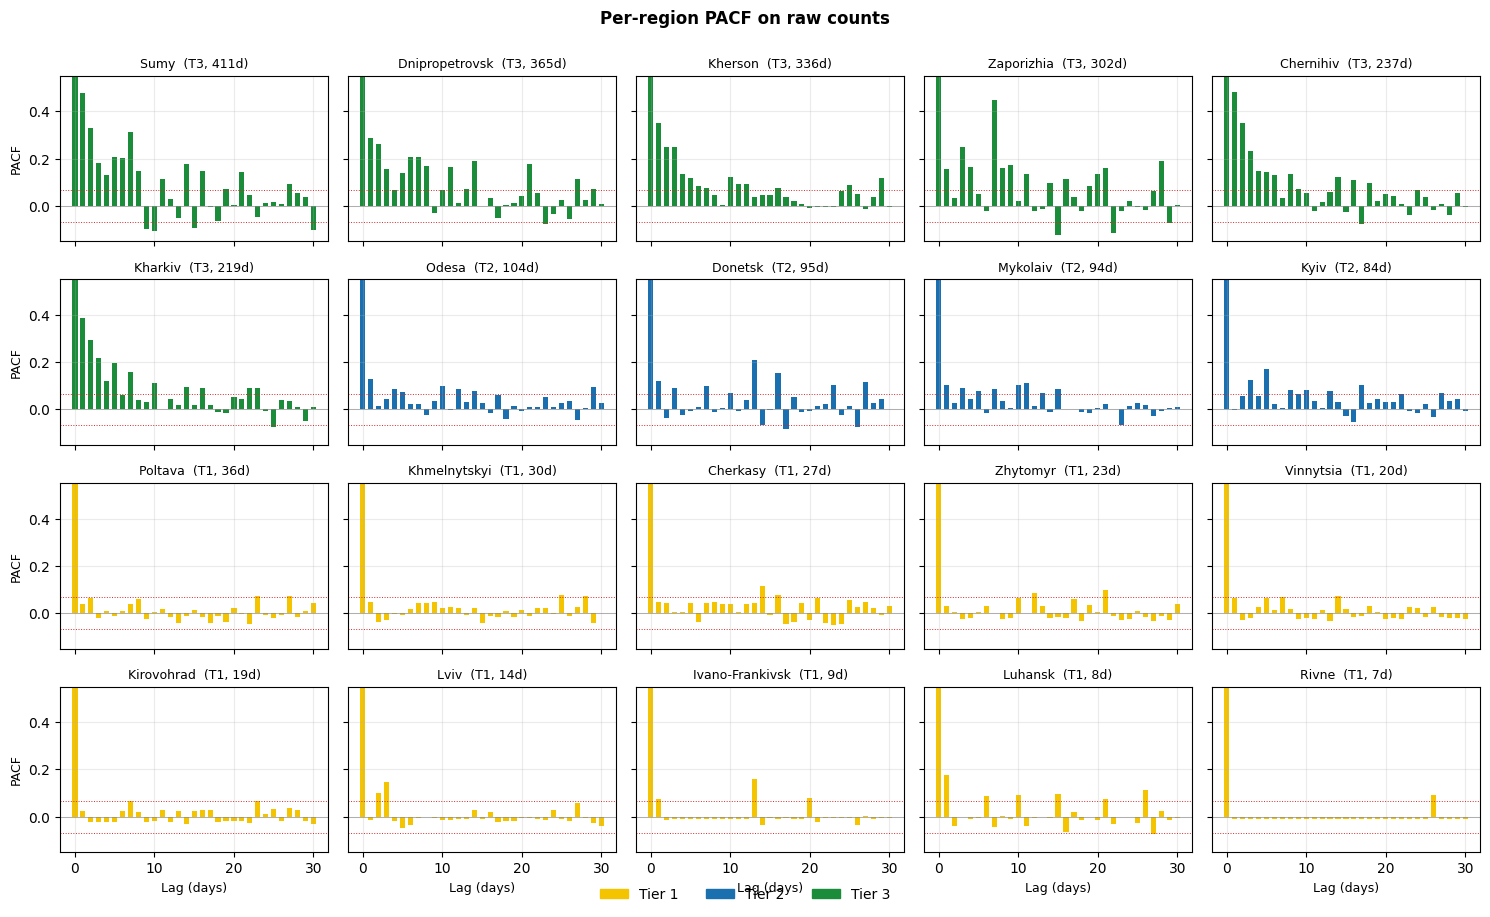

In [8]:
def plot_pacf_grid(P, regs_order, tiers_arr, active_days, max_lag=30, savepath=None):
    """Appendix figure: 4x5 small-multiples PACF grid, regions sorted by tier then activity."""
    sort_idx = sorted(range(len(regs_order)),
                      key=lambda i: (-tiers_arr[i], -active_days[regs_order[i]]))
    regs_s = [regs_order[i] for i in sort_idx]
    P_s    = P[sort_idx]
    tier_s = tiers_arr[sort_idx]
    T      = 847; ci = 1.96 / np.sqrt(T)
    lags   = np.arange(max_lag + 1)
    colors = {1:'#f5c400', 2:'#1a6faf', 3:'#1a8c3a'}

    fig, axes = plt.subplots(4, 5, figsize=(15, 9), sharex=True, sharey=True)
    for k, ax in enumerate(axes.flat):
        if k >= len(regs_s): ax.axis('off'); continue
        ax.bar(lags, P_s[k], color=colors[int(tier_s[k])], width=0.65)
        ax.axhline(ci, ls=':', color='C3', lw=0.7); ax.axhline(-ci, ls=':', color='C3', lw=0.7)
        ax.axhline(0, color='gray', lw=0.4)
        ax.set_title(f'{regs_s[k].title()}  (T{int(tier_s[k])}, {active_days[regs_s[k]]}d)', fontsize=9)
        ax.set_ylim(-0.15, 0.55); ax.grid(alpha=0.25)
    for ax in axes[-1, :]: ax.set_xlabel('Lag (days)', fontsize=9)
    for ax in axes[:, 0]:  ax.set_ylabel('PACF', fontsize=9)
    handles = [mpatches.Patch(color=colors[t], label=f'Tier {t}') for t in [1,2,3]]
    fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.005))
    plt.suptitle('Per-region PACF on raw counts', fontsize=12, fontweight='bold', y=1.00)
    plt.tight_layout()
    if savepath: plt.savefig(savepath, bbox_inches='tight')
    plt.show()

plot_pacf_grid(P, regs_order, tiers_arr, active_days, MAX_LAG, f'{OUTPUT_DIR}/fig_eda2b_pacf_grid.svg')

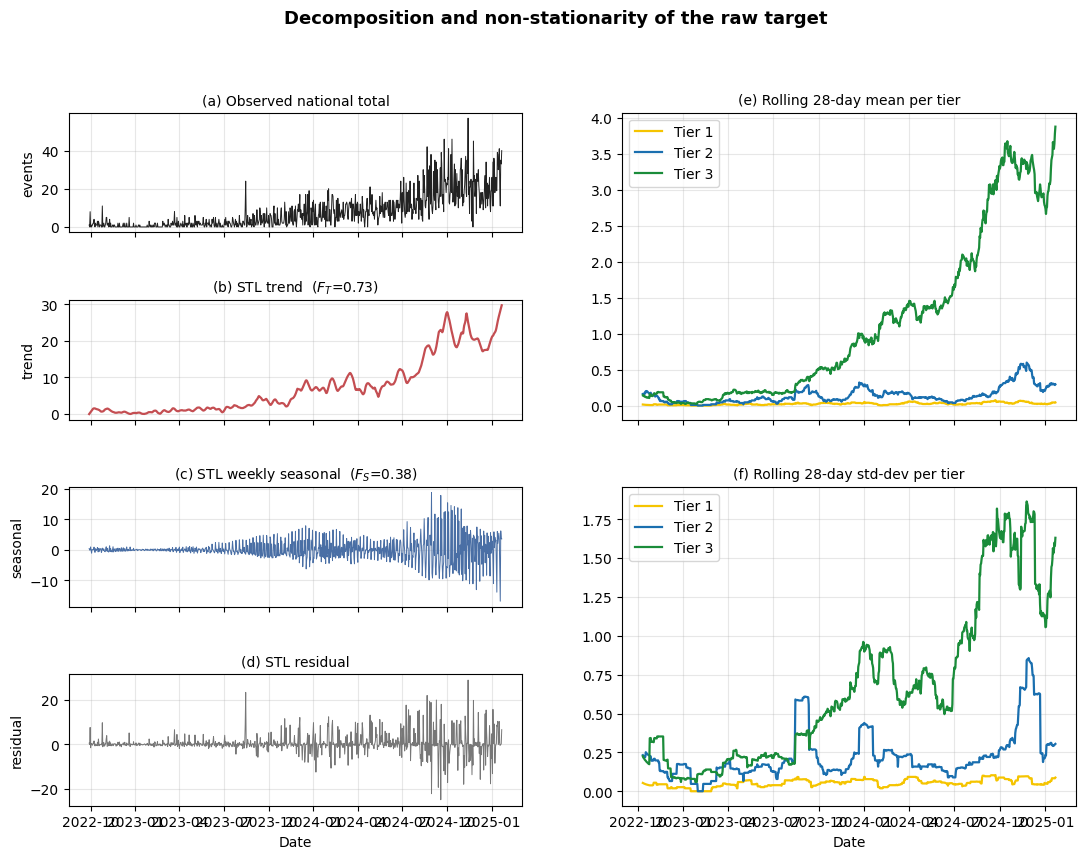

(np.float64(0.729775843027967), np.float64(0.380510706970696))

In [ ]:
def stl_decomposition(tlong, period=7):
    """STL on the national daily total.  Returns the fit + (F_T, F_S) strength scores."""
    nat = tlong.groupby('event_date')['y'].sum().sort_index().asfreq('D')
    fit = STL(nat, period=period, robust=True).fit()
    v_T = np.var(fit.trend, ddof=1)
    v_S = np.var(fit.seasonal, ddof=1)
    v_R = np.var(fit.resid, ddof=1)
    F_T = max(0.0, 1 - v_R / (v_R + v_T))
    F_S = max(0.0, 1 - v_R / (v_R + v_S))
    return fit, F_T, F_S

def plot_stl_and_rolling(tlong, savepath=None):
    fit, F_T, F_S = stl_decomposition(tlong)
    nat = tlong.groupby('event_date')['y'].sum().sort_index().asfreq('D')
    colors = {1:'#f5c400', 2:'#1a6faf', 3:'#1a8c3a'}
    fig = plt.figure(figsize=(13, 9))
    gs  = fig.add_gridspec(4, 2, hspace=0.55, wspace=0.22, height_ratios=[1,1,1,1.1])

    panels = [(0, nat.values,        f'(a) Observed national total',                'events'),
              (1, fit.trend.values,  f'(b) STL trend  ($F_T$={F_T:.2f})',           'trend'),
              (2, fit.seasonal.values, f'(c) STL weekly seasonal  ($F_S$={F_S:.2f})', 'seasonal'),
              (3, fit.resid.values,  '(d) STL residual',                            'residual')]
    for row, vals, title, ylab in panels:
        ax = fig.add_subplot(gs[row,0])
        ax.plot(nat.index, vals, lw=0.7 if row in (0,2,3) else 1.6,
                color={0:'#222', 1:'tomato', 2:'#4a6fa5', 3:'#777'}[row])
        ax.set_title(title, fontsize=10); ax.set_ylabel(ylab); ax.grid(alpha=0.3)
        if row < 3: ax.tick_params(labelbottom=False)
        else: ax.set_xlabel('Date')

    # Rolling moments per tier
    ax = fig.add_subplot(gs[0:2,1])
    for t in [1,2,3]:
        s = tlong[tlong.tier == t].groupby('event_date')['y'].mean().sort_index().asfreq('D')
        ax.plot(s.index, s.rolling(28, min_periods=14).mean().values, color=colors[t], lw=1.6, label=f'Tier {t}')
    ax.set_title('(e) Rolling 28-day mean per tier', fontsize=10); ax.legend(); ax.grid(alpha=0.3); ax.tick_params(labelbottom=False)

    ax = fig.add_subplot(gs[2:4,1])
    for t in [1,2,3]:
        s = tlong[tlong.tier == t].groupby('event_date')['y'].mean().sort_index().asfreq('D')
        ax.plot(s.index, s.rolling(28, min_periods=14).std().values, color=colors[t], lw=1.6, label=f'Tier {t}')
    ax.set_title('(f) Rolling 28-day std-dev per tier', fontsize=10); ax.legend(); ax.grid(alpha=0.3); ax.set_xlabel('Date')

    plt.suptitle('Decomposition and non-stationarity of the raw target', fontsize=13, fontweight='bold', y=0.995)
    if savepath: plt.savefig(savepath, bbox_inches='tight')
    plt.show()
    return F_T, F_S

plot_stl_and_rolling(tlong, f'{OUTPUT_DIR}/fig_eda2c_stl_rolling.svg')

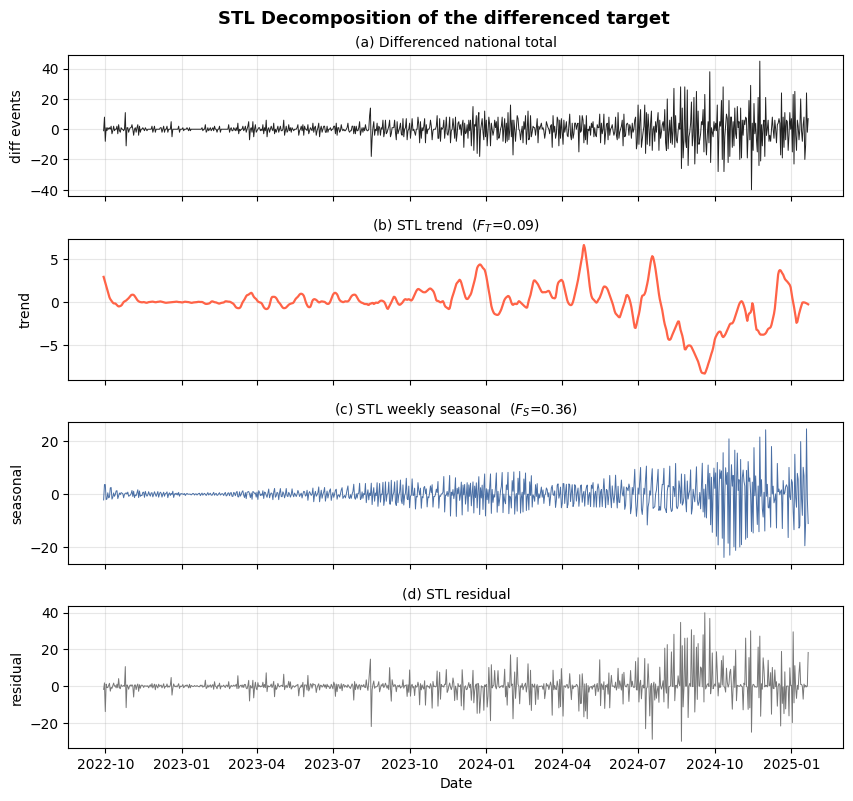

(np.float64(0.08768408874879552), np.float64(0.3571650447189041))

In [48]:
def stl_decomposition(tlong, period=7):
    """STL on the differenced national daily total. Returns the fit + (F_T, F_S) strength scores."""
    # 1. Aggregate, sort, and set frequency
    nat = tlong.groupby('event_date')['y'].sum().sort_index().asfreq('D')
    
    # 2. Apply first-order differencing and drop the NaN row
    nat_diff = nat.diff().dropna()
    
    # 3. Fit STL on the differenced data
    fit = STL(nat_diff, period=period, robust=True).fit()
    
    v_T = np.var(fit.trend, ddof=1)
    v_S = np.var(fit.seasonal, ddof=1)
    v_R = np.var(fit.resid, ddof=1)
    
    F_T = max(0.0, 1 - v_R / (v_R + v_T))
    F_S = max(0.0, 1 - v_R / (v_R + v_S))
    
    return fit, F_T, F_S, nat_diff

def plot_stl(tlong, savepath=None):
    # Unpack all 4 values
    fit, F_T, F_S, nat_diff = stl_decomposition(tlong)
    
    # Create a 4-row, 1-column layout (adjusted width for single column)
    fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True, gridspec_kw={'hspace': 0.3})

    # Define the 4 panels
    panels = [(0, nat_diff.values,       f'(a) Differenced national total',            'diff events'),
              (1, fit.trend.values,  f'(b) STL trend  ($F_T$={F_T:.2f})',           'trend'),
              (2, fit.seasonal.values, f'(c) STL weekly seasonal  ($F_S$={F_S:.2f})', 'seasonal'),
              (3, fit.resid.values,  '(d) STL residual',                            'residual')]
              
    for row, vals, title, ylab in panels:
        ax = axes[row]
        ax.plot(nat_diff.index, vals, lw=0.7 if row in (0,2,3) else 1.6,
                color={0:'#222', 1:'tomato', 2:'#4a6fa5', 3:'#777'}[row])
        ax.set_title(title, fontsize=10)
        ax.set_ylabel(ylab)
        ax.grid(alpha=0.3)
        
        # Only add the X-label to the bottom plot
        if row == 3: 
            ax.set_xlabel('Date')

    # Update title to reflect the removed rolling stats
    plt.suptitle('STL Decomposition of the differenced target', fontsize=13, fontweight='bold', y=0.93)
    
    if savepath: 
        plt.savefig(savepath, bbox_inches='tight')
    plt.show()
    
    return F_T, F_S

# Call the updated function
plot_stl(tlong, f'{OUTPUT_DIR}/fig_eda2c_stl.svg')

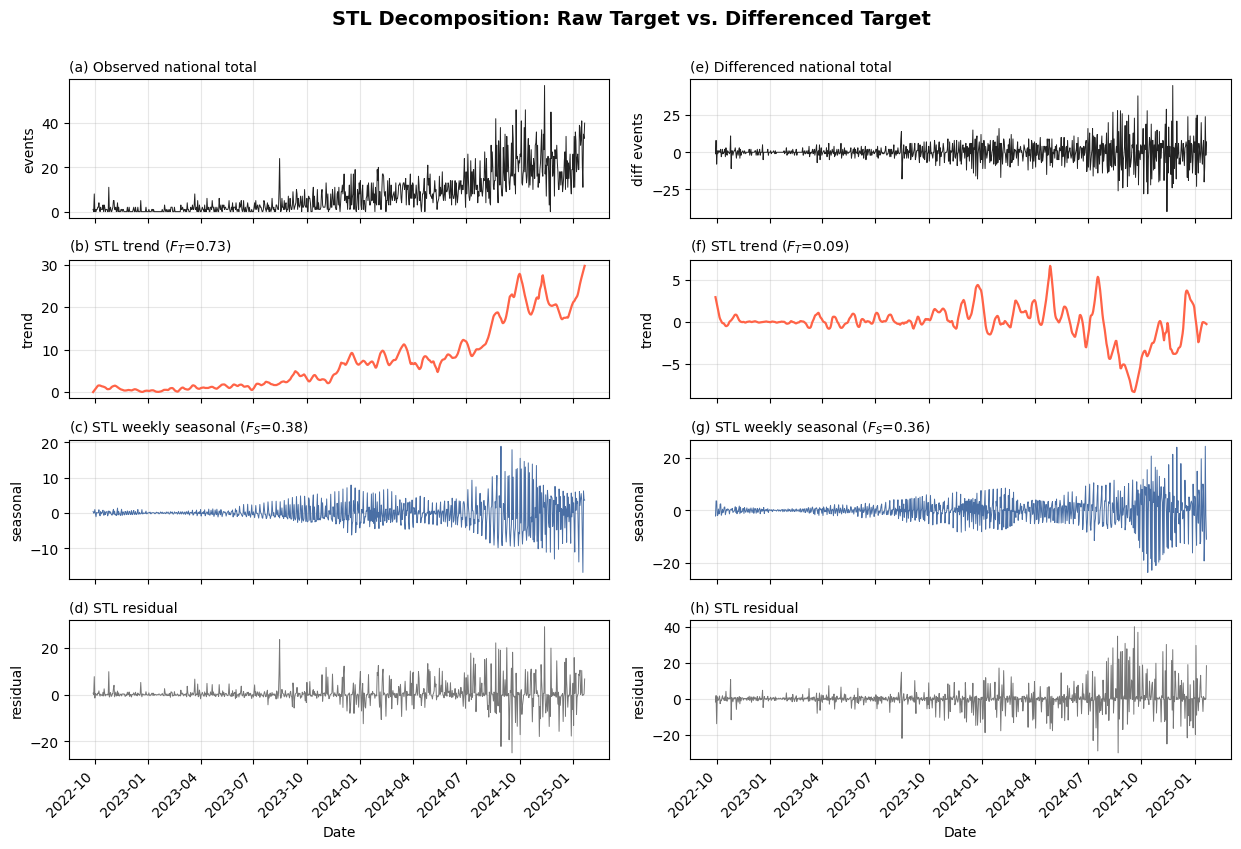

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

def get_stl_components(series, period=7):
    """Helper function to run STL and return the fit + strength scores."""
    fit = STL(series, period=period, robust=True).fit()
    
    v_T = np.var(fit.trend, ddof=1)
    v_S = np.var(fit.seasonal, ddof=1)
    v_R = np.var(fit.resid, ddof=1)
    
    F_T = max(0.0, 1 - v_R / (v_R + v_T))
    F_S = max(0.0, 1 - v_R / (v_R + v_S))
    
    return fit, F_T, F_S

def plot_side_by_side_stl(tlong, savepath=None):
    # 1. Prepare both data versions
    nat = tlong.groupby('event_date')['y'].sum().sort_index().asfreq('D')
    nat_diff = nat.diff().dropna()
    
    # 2. Compute STL for both
    fit_raw, FT_raw, FS_raw = get_stl_components(nat)
    fit_diff, FT_diff, FS_diff = get_stl_components(nat_diff)
    
    # 3. Set up the 4x2 plot layout
    fig, axes = plt.subplots(4, 2, figsize=(15, 10), sharex=True, 
                             gridspec_kw={'hspace': 0.3, 'wspace': 0.15})
    
    # 4. Define panels for the Left Column (Raw)
    panels_left = [
        (0, nat.values,          '(a) Observed national total',                 'events'),
        (1, fit_raw.trend.values,    f'(b) STL trend ($F_T$={FT_raw:.2f})',         'trend'),
        (2, fit_raw.seasonal.values, f'(c) STL weekly seasonal ($F_S$={FS_raw:.2f})', 'seasonal'),
        (3, fit_raw.resid.values,    '(d) STL residual',                            'residual')
    ]
    
    # 5. Define panels for the Right Column (Differenced)
    panels_right = [
        (0, nat_diff.values,          '(e) Differenced national total',                 'diff events'),
        (1, fit_diff.trend.values,    f'(f) STL trend ($F_T$={FT_diff:.2f})',         'trend'),
        (2, fit_diff.seasonal.values, f'(g) STL weekly seasonal ($F_S$={FS_diff:.2f})', 'seasonal'),
        (3, fit_diff.resid.values,    '(h) STL residual',                               'residual')
    ]
    
    colors = {0: '#222', 1: 'tomato', 2: '#4a6fa5', 3: '#777'}
    
    # 6. Plot Left Column
    for row, vals, title, ylab in panels_left:
        ax = axes[row, 0]
        ax.plot(nat.index, vals, lw=0.7 if row in (0,2,3) else 1.6, color=colors[row])
        ax.set_title(title, fontsize=10, loc='left')
        ax.set_ylabel(ylab)
        ax.grid(alpha=0.3)
        if row == 3: 
            ax.set_xlabel('Date')

    # 7. Plot Right Column
    for row, vals, title, ylab in panels_right:
        ax = axes[row, 1]
        ax.plot(nat_diff.index, vals, lw=0.7 if row in (0,2,3) else 1.6, color=colors[row])
        ax.set_title(title, fontsize=10, loc='left')
        ax.set_ylabel(ylab)
        ax.grid(alpha=0.3)
        if row == 3: 
            ax.set_xlabel('Date')

    # 8. Final touches
    fig.autofmt_xdate(rotation=45)
    plt.suptitle('STL Decomposition: Raw Target vs. Differenced Target', 
                 fontsize=14, fontweight='bold', y=0.95)
    
    if savepath: 
        plt.savefig(savepath, bbox_inches='tight')
    plt.show()

# Execute the plot
plot_side_by_side_stl(tlong, savepath=f'{OUTPUT_DIR}/fig_eda2c_stl_side_by_side.svg')

## Block 3 — Stationarity diagnostics

In [10]:
def stationarity_per_region(tlong, active_days, tier_map):
    """ADF (H0: unit root) + KPSS (H0: stationary) per region on raw counts."""
    rows = []
    for r, sub in tlong.groupby('region'):
        x = sub.sort_values('event_date')['y'].values.astype(float)
        adf_p  = adfuller(x, autolag='AIC')[1]
        kpss_p = kpss(x, regression='c', nlags='auto')[1]
        if   adf_p < 0.05 and kpss_p >= 0.05: v = 'stationary'
        elif adf_p >= 0.05 and kpss_p < 0.05: v = 'non-stationary'
        elif adf_p < 0.05 and kpss_p < 0.05:  v = 'difference-stationary'
        else: v = 'inconclusive'
        rows.append({'region': r, 'tier': tier_map[r], 'active_days': active_days[r],
                     'adf_p': adf_p, 'kpss_p': kpss_p, 'verdict': v})
    return pd.DataFrame(rows).sort_values(['tier','active_days'], ascending=[False,False])

stat_df = stationarity_per_region(tlong, active_days, tier)
print(stat_df.to_string(index=False))
print(pd.crosstab(stat_df['tier'], stat_df['verdict']))

         region  tier  active_days        adf_p   kpss_p               verdict
           sumy     3          411 9.543295e-01 0.010000        non-stationary
 dnipropetrovsk     3          365 5.214759e-01 0.010000        non-stationary
        kherson     3          336 2.491230e-01 0.010000        non-stationary
     zaporizhia     3          302 5.005110e-01 0.010000        non-stationary
      chernihiv     3          237 9.943107e-01 0.010000        non-stationary
        kharkiv     3          219 7.937270e-01 0.010000        non-stationary
          odesa     2          104 7.863818e-06 0.010000 difference-stationary
        donetsk     2           95 9.369843e-05 0.010000 difference-stationary
       mykolaiv     2           94 1.392500e-04 0.010000 difference-stationary
           kyiv     2           84 5.950366e-04 0.010000 difference-stationary
        poltava     1           36 2.059693e-30 0.010000 difference-stationary
   khmelnytskyi     1           30 0.000000e+00 0.02

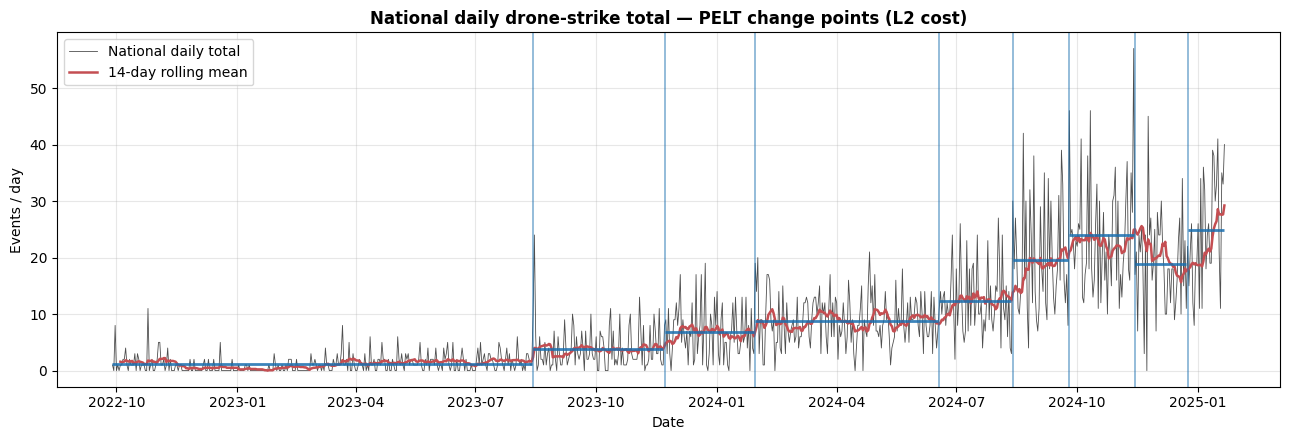

,segment,start,end,len_days,mean,std
0,1,2022-09-28,2023-08-13,320,1.178125,1.562538
1,2,2023-08-14,2023-11-21,100,3.880000,3.790685
2,3,2023-11-22,2024-01-29,69,6.753623,4.726041
3,4,2024-01-30,2024-06-17,140,8.864286,4.461201
4,5,2024-06-18,2024-08-12,56,12.339286,6.114890
5,6,2024-08-13,2024-09-24,43,19.558140,9.998339
6,7,2024-09-25,2024-11-13,50,23.920000,10.251610
7,8,2024-11-14,2024-12-23,40,18.825000,8.667320
8,9,2024-12-24,2025-01-21,29,24.793103,9.879196


In [ ]:
def changepoint_pelt(tlong, min_seg=28, savepath=None):
    """PELT (L2 cost) on national daily total with a robust σ²-calibrated penalty."""
    nat = tlong.groupby('event_date')['y'].sum().sort_index()
    x   = nat.values.astype(float); n = len(x)
    sigma2 = np.median(np.diff(x)**2) / 2.0
    pen    = 2.0 * sigma2 * np.log(n)
    bkps   = rpt.Pelt(model='l2', min_size=min_seg, jump=1).fit(x).predict(pen=pen)
    segs   = list(zip([0] + bkps[:-1], bkps))
    seg_df = pd.DataFrame([{
        'segment': i+1, 'start': nat.index[s].date(), 'end': nat.index[min(e-1, n-1)].date(),
        'len_days': e-s, 'mean': float(x[s:e].mean()), 'std': float(x[s:e].std(ddof=1))
    } for i, (s,e) in enumerate(segs)])
    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax.plot(nat.index, x, color='#222', lw=0.6, alpha=0.8, label='National daily total')
    rm = pd.Series(x, index=nat.index).rolling(14, min_periods=7).mean()
    ax.plot(rm.index, rm.values, color='tomato', lw=1.8, label='14-day rolling mean')
    for s, e in segs:
        ax.hlines(x[s:e].mean(), nat.index[s], nat.index[min(e-1, n-1)], color='#1a6faf', lw=2.0, alpha=0.85)
    for b in bkps[:-1]:
        ax.axvline(nat.index[b], color='#1a6faf', ls='-', lw=1.2, alpha=0.55)
    ax.set_title('National daily drone-strike total — PELT change points (L2 cost)', fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel('Events / day'); ax.legend(loc='upper left'); ax.grid(alpha=0.3)
    plt.tight_layout()
    if savepath: plt.savefig(savepath, bbox_inches='tight')
    plt.show()
    return seg_df

changepoint_pelt(tlong, savepath=f'{OUTPUT_DIR}/fig_eda3_changepoints.svg')

## Block 5 — Covariate–target relationships

In [13]:
def categorise_columns(df, modelled_regions, target_prefix):
    """Split columns into (region-suffixed bases, national covariates)."""
    region_suffixes = sorted(set(modelled_regions), key=lambda s: -len(s))
    def region_suffix(c):
        for r in region_suffixes:
            if c.endswith('_' + r): return r
        return None
    region_bases = set(); national = []
    for c in df.columns:
        if c == 'event_date' or c.startswith(target_prefix): continue
        r = region_suffix(c)
        if r is not None: region_bases.add(c[: -(len(r)+1)])
        else:             national.append(c)
    return sorted(region_bases), national

def within_region_spearman(df, region_bases, modelled, target_prefix):
    rows = []
    for base in region_bases:
        if base == target_prefix.rstrip('_'): continue
        rhos = []
        for r in modelled:
            col = f'{base}_{r}'
            if col not in df.columns: continue
            x, y = df[col].values, df[f'{target_prefix}{r}'].values
            if np.std(x) == 0 or np.std(y) == 0: continue
            rho, _ = spearmanr(x, y)
            if not np.isnan(rho): rhos.append(rho)
        if len(rhos) >= 5:
            rows.append({'base': base, 'n_regions': len(rhos),
                         'median_rho': float(np.median(rhos)),
                         'q25_rho': float(np.percentile(rhos, 25)),
                         'q75_rho': float(np.percentile(rhos, 75))})
    return pd.DataFrame(rows).sort_values('median_rho', key=lambda s: -s.abs())

region_bases, national_cov = categorise_columns(df, modelled, TARGET_PREFIX)
wrs = within_region_spearman(df, region_bases, modelled, TARGET_PREFIX)
wrs.head(20)

,base,n_regions,median_rho,q25_rho,q75_rho
19,act_drone_infra_ua_residential_intent,18,0.340891,0.283814,0.383636
20,act_drone_infra_ua_residential_unintent,17,0.263919,0.114292,0.358132
17,act_drone_infra_ua_energy_unintent,9,0.207684,0.156869,0.230621
16,act_drone_infra_ua_energy_intent,18,0.200660,0.139885,0.404595
14,act_drone_infra_ua_education_intent,14,0.166717,0.103490,0.214883
18,act_drone_infra_ua_health_intent,8,0.123423,0.092224,0.184532
15,act_drone_infra_ua_education_unintent,6,0.119023,0.072763,0.145994
23,dist_to_nearest_ru_km,10,-0.091217,-0.386428,-0.027951
10,acled_other_ua_disrupted_weapons_use,20,0.061614,0.028493,0.118312
37,env_weather_soil_moisture_0_to_100cm_mean,20,-0.057859,-0.134248,-0.019256


## Block 6 + 7 — Missingness and split shift

In [15]:
def missingness_audit(df, target_cols):
    na = df.isna().sum()
    return {
        'columns_with_nan': int((na > 0).sum()),
        'target_nans': int(df[target_cols].isna().sum().sum()),
        'dates_fully_missing': int(df[target_cols].isna().all(axis=1).sum()),
    }

def split_shift_table(df, tier_map, modelled, target_prefix, train_end, val_end):
    df = df.copy()
    df['split'] = np.where(df['event_date'] <= train_end, 'train',
                   np.where(df['event_date'] <= val_end,   'val', 'test'))
    rows = []
    for split in ['train','val','test']:
        sub = df[df.split == split]
        for t in [1,2,3]:
            cols = [f'{target_prefix}{r}' for r in modelled if tier_map[r]==t]
            yy = sub[cols].values.flatten()
            rows.append({'split':split,'tier':t,'n_obs':len(yy),
                         'zero_rate':float((yy==0).mean()),'mean':float(yy.mean()),
                         'std':float(yy.std(ddof=1)),'p95':float(np.percentile(yy,95)),
                         'p99':float(np.percentile(yy,99)),'max':int(yy.max())})
    return pd.DataFrame(rows)

print(missingness_audit(df, [TARGET_PREFIX + r for r in modelled]))
shift_df = split_shift_table(df, tier, modelled, TARGET_PREFIX, TRAIN_END, VAL_END)
print(shift_df.to_string(index=False))

{'columns_with_nan': 0, 'target_nans': 0, 'dates_fully_missing': 0}
split  tier  n_obs  zero_rate     mean      std  p95  p99  max
train     1   5920   0.982601 0.019426 0.152007  0.0  1.0    2
train     2   2368   0.911740 0.108953 0.433051  1.0  2.0   11
train     3   3552   0.775901 0.500845 1.326463  3.0  7.0   15
  val     1    850   0.974118 0.027059 0.169450  0.0  1.0    2
  val     2    340   0.926471 0.076471 0.277003  1.0  1.0    2
  val     3    510   0.435294 1.717647 2.337589  6.0 10.0   14
 test     1   1700   0.960000 0.042353 0.215566  0.0  1.0    3
 test     2    680   0.789706 0.307353 0.865611  1.0  3.0   11
 test     3   1020   0.229412 3.249020 3.910524 10.0 20.0   37
